# Explore here

In [5]:
# Paso 1 Carga de datos 

import pandas as pd
import os 
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir la URL y la ruta del destino
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
target_dir= "data/raw" 
target_file = "medical_insurance_cost.csv"
target_path = os.path.join (target_dir, target_file) 

# 2. Cargar los datos
print ("Cargando datos desde la URL")
df = pd.read_csv(url)
print ("Datos cargados exitosamente.")

# 3. CREAR LA CARPETA SI NO EXISTE

if not os.path.exists(target_dir):
    print(f"La carpeta '{target_dir}' no existe. Creándola...")
    os.makedirs(target_dir) #makedirs crea todas las carpetas intermedias (data, raw)
    print("Carpeta creada.")
else:
    print(f"La carpeta '{target_dir}' ya existe.")

# 4. Guardar una copia en la carpeta 'raw'
print(f"Guardando archivo en '{target_path}'...")
df.to_csv(target_path, index=False)

print(f"¡Hecho! Archivo guardado exitosamente en: {target_path}")

# 5.ver las primeras filas para confirmar que todo está bien
print("\nPrimeras filas del dataset cargado:")
display(df.head())


Cargando datos desde la URL
Datos cargados exitosamente.
La carpeta 'data/raw' ya existe.
Guardando archivo en 'data/raw/medical_insurance_cost.csv'...
¡Hecho! Archivo guardado exitosamente en: data/raw/medical_insurance_cost.csv

Primeras filas del dataset cargado:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


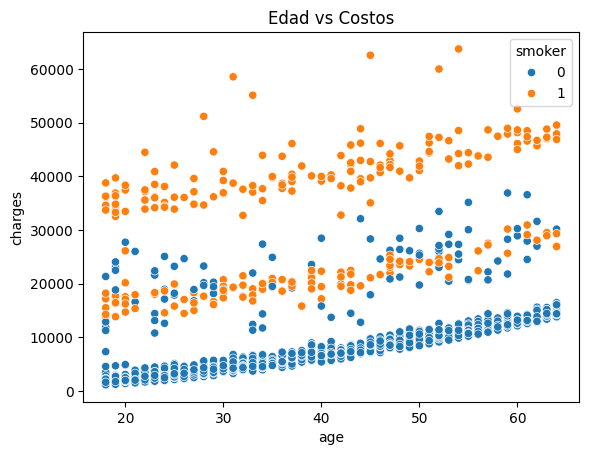

In [6]:
# Paso 2 Análisis Exploratorio de Datos (EDA)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Asegurar que df esté definido (si el cell 1 no se ejecutó antes)
if 'df' not in globals():
	url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
	df = pd.read_csv(url)

# Convertir categóricas a numéricas (Encoding)
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Definir variables predictoras (X) y objetivo (y)
X = df.drop('charges', axis=1)
y = df['charges']

# División en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Un pequeño gráfico para ver la relación más fuerte (fumadores vs costos)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title("Edad vs Costos")
plt.show()

In [7]:
# Paso 3. Crear el modelo 
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

In [9]:
# Paso 4. Análisis y Optimización
from sklearn.metrics import mean_squared_error, r2_score

# Evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar resultados

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

Error Cuadrático Medio (MSE): 33596915.85
Coeficiente de Determinación (R2): 0.7836


In [ ]:
# Análisis de los resultados 
# R2 de 78% Este es un resultado de regresión lineal simple; lo que quiere decir que las variables como la edad, el IMC y si la persona fuma explican la gran mayoria del costo del seguro.
# MSE 33,59 Veredicto: En promedio, las predicciones del modelo se equivocan por unos 5,796 USD. Dependiendo de si la prima es de 10,000 o 40,000 USD, este error puede ser alto.

In [10]:
# Paso 5. Mejorar el modelo 

# Crear la nueva variable de interacción
df['bmi_smoker'] = df['bmi'] * df['smoker']

# Definir de nuevo X (ahora incluye la nueva columna) e y
X = df.drop('charges', axis=1)
y = df['charges']

# Dividir nuevamente en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Nueva variable 'bmi_smoker' creada exitosamente.")

Nueva variable 'bmi_smoker' creada exitosamente.


In [11]:
# 6. Reentrenamiento y evaluacion del modelo

# Crear y entrenar el nuevo modelo
model_opt = LinearRegression()
model_opt.fit(X_train, y_train)

# Predicciones
y_pred_opt = model_opt.predict(X_test)

# Nuevas métricas
mse_opt = mean_squared_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print(f"Nuevo MSE: {mse_opt}")
print(f"Nuevo R2 Score: {r2_opt}")

Nuevo MSE: 20919716.751168985
Nuevo R2 Score: 0.8652503208873078


In [ ]:
# Implementacion del mejoramiento del modelo con XGBoost
import xgboost as xg

In [ ]:
import xgboost as xg
from sklearn.metrics import mean_squared_error, r2_score

# 1. Usamos parámetros estándar para empezar
xgb_model = xg.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

# 2. Entrenar el modelo

xgb_model.fit(X_train, y_train)

# 3. Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluación
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MSE: {mse_xgb}")
print(f"XGBoost R2 Score: {r2_xgb}")

XGBoost MSE: 18130330.78611514
XGBoost R2 Score: 0.8832175270489997


Bad pipe message: %s [b'\xad\xabU\x84\xed\xb3\xd6W\xce\xc6Y{1*[\xa7d\x97\x00\x00\x80\x00\x1d\x00\x1c\xfe\xff\xfe\xfe\x00c\x00e\x00\x11\x00r\x00\x13\x00s\x002\x00@\x00\xa2\x00t\x008\x00j\x00\xa3\xc0B\xc0V\xc0C\xc0W\x00D\x00\xbd\xc0\x80\x00\x87\x00\xc3\xc0\x81\x00\x12\x00f\x00\x99\x00\x8f\x00\x90\x00\xb2\xc0\xa6\x00\xaa\x00\x91\x00\xb3\xc0\xa7\x00\xab\xc0f\xc0l\xc0g\xc0m\xc0\x96\xc0\x90\xc0\x97\xc0\x91\xcc\xad\x00-\x00\xb4\x00\xb5\x00\x8e\x00\x14\x00w\x00\x16\x00x\x003\x00g\xc0\x9e\xc0\xa2\x00\x9e\x00y\x009\x00k\x01\x00\x006\x00\n\x00\x0c\x00\n\x00\x17\x00\x18\x00\x19\x00\x1d\x01\x00\x00\x0b\x00\x02\x01\x00']
Bad pipe message: %s [b']\x19\xd5\xa6\xed?\x91%G \xaa\xabI\x90\xfc\xd2\xb8\xd1\x00\x00\x80\xc0\x9f\xc0\xa3\x00\x9f\xc0D\xc0R\xc0E\xc0S\x00E\x00\xbe\xc0|\x00\x88\x00\xc4\xc0}\xcc\xaa\xcc\x15\x00\x15\x00\x9a\x00\x0b\x00\r\x000\x00>\x00\xa4\x006\x00h\x00\xa5\xc0>\xc0X\xc0?\xc0Y\x00B\x00\xbb\xc0\x82\x00\x85\x00\xc1\xc0\x83\x00\x0c\x00\x97\x00\x0e\x00\x10\x001\x00?\x00\xa0\x007\x00i\x00\

In [ ]:
# Aálisis de resultados
# Si el R2 de XGBoost es significativamente mayor que el de la regresión lineal, esto indicaría que el modelo de XGBoost captura mejor las relaciones complejas entre las variables y el costo del seguro. Un MSE más bajo también confirmaría que las predicciones de XGBoost son más precisas en promedio.

In [13]:
import pickle

# Guardar el modelo en un archivo llamado 'medical_model_xgb.pkl'
filename = 'medical_model_xgb.pkl'
pickle.dump(xgb_model, open(filename, 'wb'))

print(f"Modelo guardado exitosamente como {filename}")

Modelo guardado exitosamente como medical_model_xgb.pkl


<Figure size 1000x800 with 0 Axes>

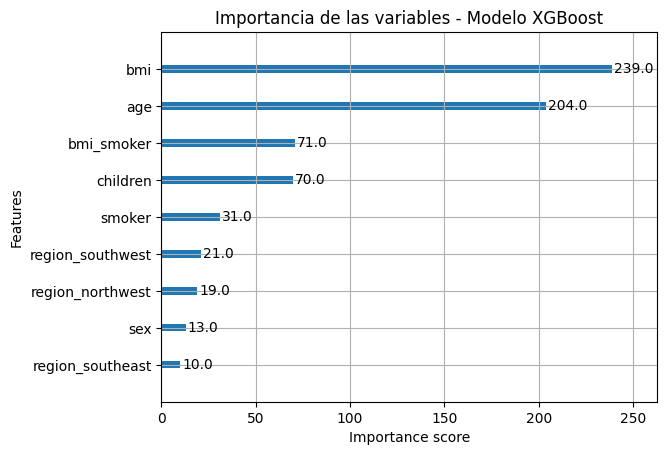

In [14]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generar el gráfico de importancia
# 'weight' indica cuántas veces se usó una variable para dividir los datos en los árboles
plot_importance(xgb_model, importance_type='weight')

plt.title("Importancia de las variables - Modelo XGBoost")
plt.show()

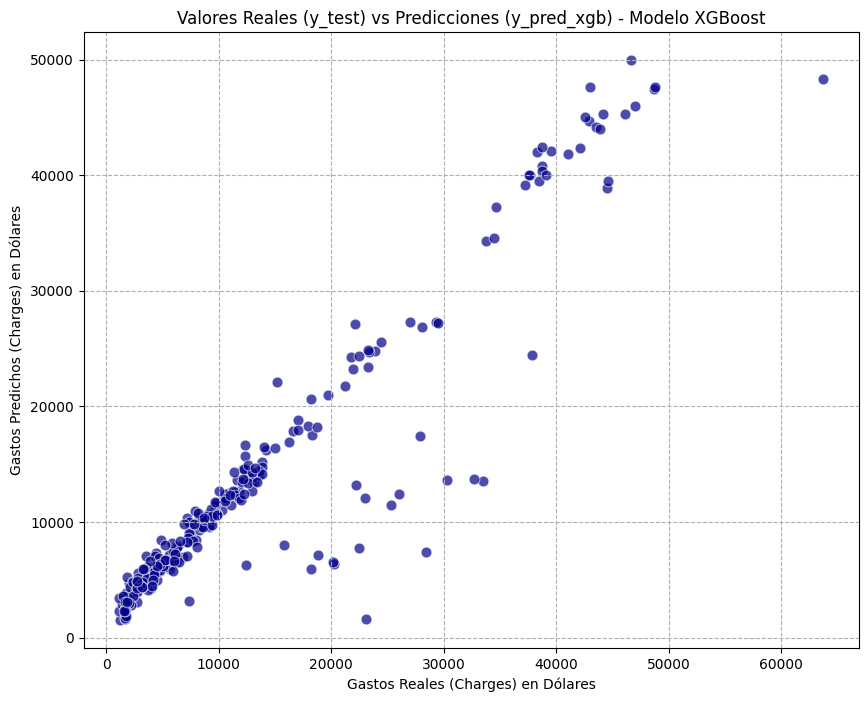

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Generar el gráfico de dispersión
# 's' es el tamaño de los puntos
# 'alpha' es la transparencia para ver superposiciones
sns.scatterplot(x=y_test, y=y_pred_xgb, s=60, alpha=0.7, color='darkblue')

# Añadir la línea de predicción perfecta (diagonal)
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

# Configurar etiquetas y título
plt.title("Valores Reales (y_test) vs Predicciones (y_pred_xgb) - Modelo XGBoost")
plt.xlabel("Gastos Reales (Charges) en Dólares")
plt.ylabel("Gastos Predichos (Charges) en Dólares")

# plt.text(min(y_test)+1000, max(y_test)-1000, "La línea roja es la predicción perfecta", color='red')

plt.grid(axis='both', linestyle='--')
plt.show()

In [16]:
# Ejemplo real de predicción con el modelo XGBoost
# Supongamos que queremos predecir el costo del seguro para una persona con las siguientes características:

import pandas as pd

# 1. Definir los datos de la persona
# Asumiremos valores por defecto para las variables que no mencionaste (ej. hijos o región)
nuevos_datos = {
    'age': [30],
    'sex': [1],          # 1 para hombre, 0 para mujer
    'bmi': [28.0],
    'children': [0],     # Asumimos 0 hijos
    'smoker': [1],       # 1 para sí (fumador)
    'region_northwest': [0], 
    'region_southeast': [0],
    'region_southwest': [0] # Todos en 0 significa que es de la región 'northeast'
}

# 2. Crear un DataFrame con estos datos
df_cliente = pd.DataFrame(nuevos_datos)

# 3. IMPORTANTE: Calcular la variable de interacción que creamos en el EDA/Optimización
df_cliente['bmi_smoker'] = df_cliente['bmi'] * df_cliente['smoker']

# 4. Asegurar el orden de las columnas (debe ser igual a X_train)
# Si tu X_train tiene un orden específico, asegúrate de que df_cliente lo siga
df_cliente = df_cliente[X_train.columns]

# 5. Realizar la predicción
prediccion = xgb_model.predict(df_cliente)

print(f"--- Resultado de la Predicción ---")
print(f"El costo estimado del seguro para esta persona es de: ${prediccion[0]:,.2f} USD")

--- Resultado de la Predicción ---
El costo estimado del seguro para esta persona es de: $18,417.30 USD
